 **Titanic Dataset Analysis**

**Data Analysis Project**

**Name:** Priya Dharshini R.\
**Course:** B.Tech Artificial Intelligence and Data Science\
**Project:** Titanic Survival Analysis






**Titanic Dataset Analysis**

**Data Analysis Project**

This project analyzes the Titanic dataset to understand the survival patterns of passengers.

**Objectives**
- Understand the Titanic dataset
- Perform data cleaning
- Analyze passenger survival
- Compare survival based on gender and passenger class
- Analyze age and fare patterns
- Visualize important survival insights

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [24]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv


In [25]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


**1. Understanding the Dataset**

First, we inspect the first few records of the Titanic dataset.

In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [27]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 891
Number of columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**2. Statistical Summary**

The statistical summary helps us understand the numerical variables such as age, fare, and passenger class.

In [28]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**3. Data Cleaning**

We check the dataset for missing values before performing the analysis.

In [29]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [30]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [31]:
df = df.drop(columns=["Cabin"])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


**4. Overall Survival Analysis**

We analyze how many passengers survived and how many did not survive.

In [32]:
survival_counts = df["Survived"].value_counts()

print("Did not survive:", survival_counts[0])
print("Survived:", survival_counts[1])

Did not survive: 549
Survived: 342


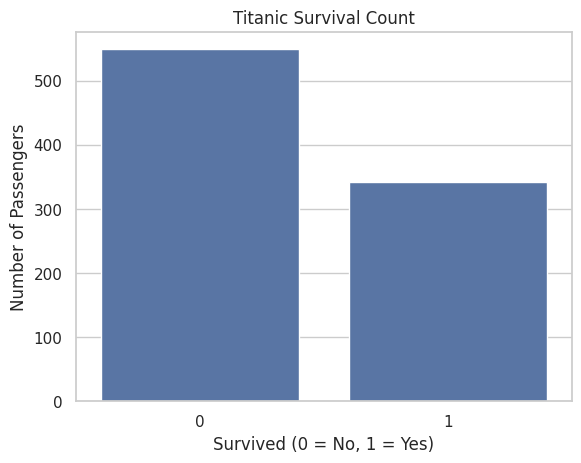

In [33]:
sns.countplot(data=df, x="Survived")

plt.title("Titanic Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

In [34]:
survival_percentage = df["Survived"].value_counts(normalize=True) * 100

print("Survival Percentage:")
print(survival_percentage)

Survival Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


**5. Gender and Survival Analysis**

We compare the survival of male and female passengers.

In [35]:
gender_survival = pd.crosstab(df["Sex"], df["Survived"])

print(gender_survival)

Survived    0    1
Sex               
female     81  233
male      468  109


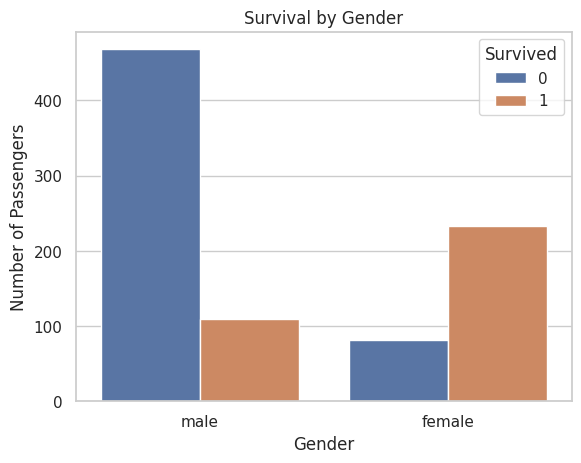

In [36]:
sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

In [37]:
gender_survival_rate = df.groupby("Sex")["Survived"].mean() * 100

print(gender_survival_rate)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


**6. Passenger Class and Survival**

We analyze whether passenger class was related to survival.

In [38]:
class_survival = pd.crosstab(df["Pclass"], df["Survived"])

print(class_survival)

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


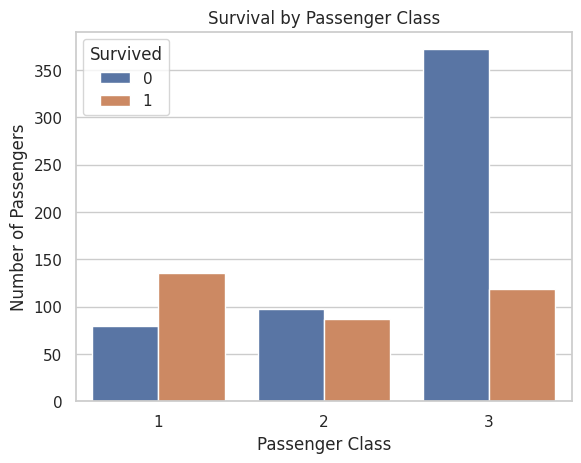

In [39]:
sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

In [40]:
class_survival_rate = df.groupby("Pclass")["Survived"].mean() * 100

print(class_survival_rate)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


 **7. Age Analysis**

We examine the age distribution of passengers and compare age with survival.

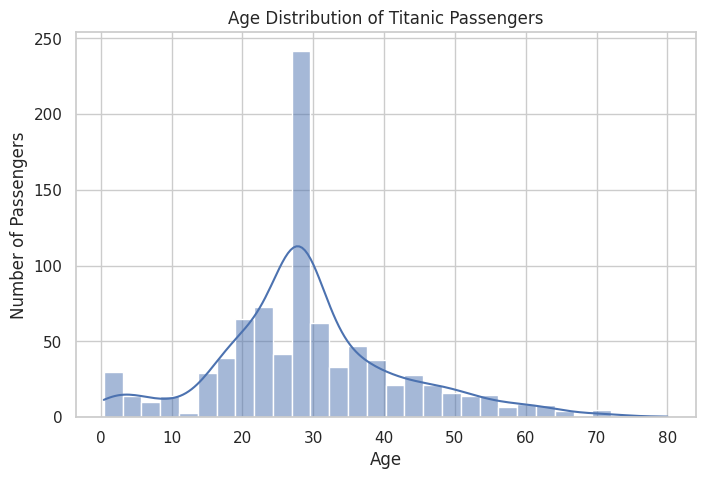

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

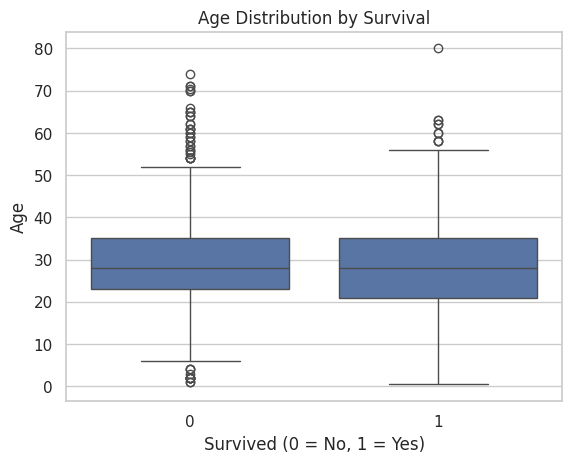

In [42]:
sns.boxplot(data=df, x="Survived", y="Age")

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

 **8. Fare Analysis**

We analyze the fare paid by passengers and compare it with survival.

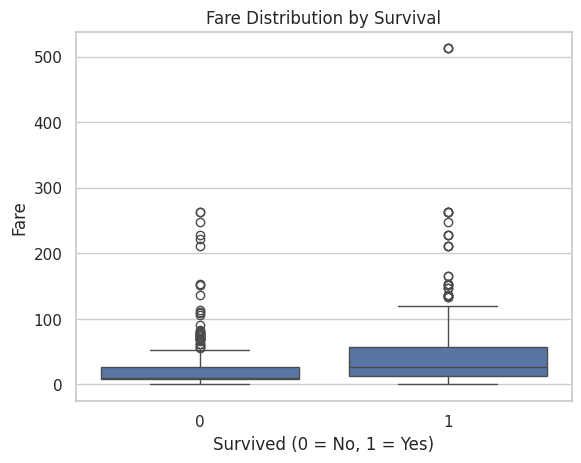

In [43]:
sns.boxplot(data=df, x="Survived", y="Fare")

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.show()

**9. Embarkation Analysis**

We compare survival based on the passenger's embarkation location.

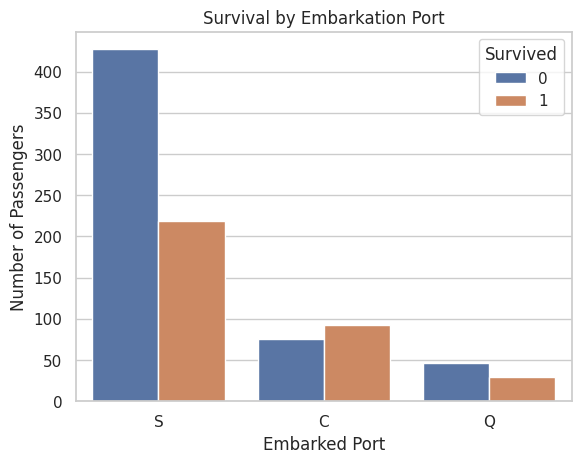

In [44]:
sns.countplot(data=df, x="Embarked", hue="Survived")

plt.title("Survival by Embarkation Port")
plt.xlabel("Embarked Port")
plt.ylabel("Number of Passengers")
plt.show()

**10. Correlation Analysis**

Correlation helps us understand the relationship between numerical variables in the dataset.

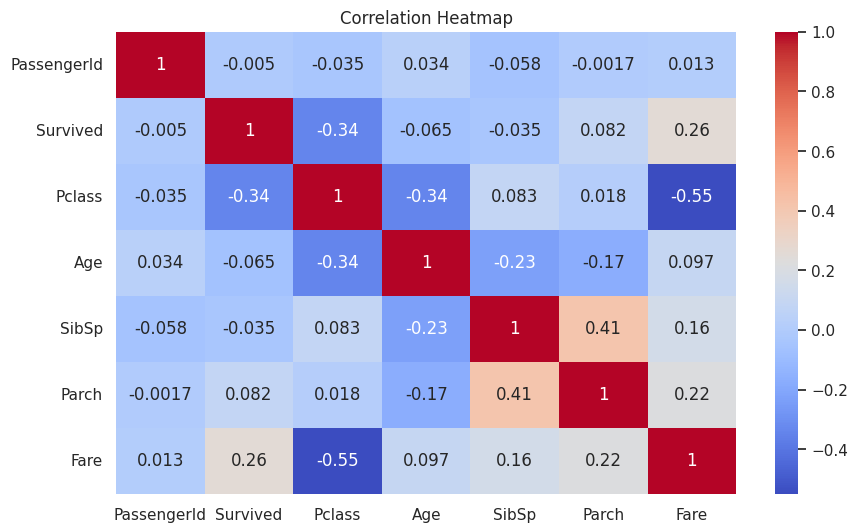

In [45]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

**11. Key Survival Insights**

The Titanic dataset shows different survival patterns based on passenger characteristics such as gender, passenger class, age and fare.

- Survival differed between male and female passengers.
- Passenger class was associated with different survival rates.
- Age distribution varied among passengers.
- Fare values differed between passengers who survived and those who did not.
- Embarkation location also showed differences in survival counts.

These observations help us understand the major factors associated with survival in the Titanic dataset.

 **Conclusion**

The Titanic dataset was analyzed using Python, Pandas, Matplotlib and Seaborn. Data cleaning was performed to handle missing values. Different visualizations were created to study survival based on gender, passenger class, age, fare and embarkation location.

The analysis demonstrates how data science and visualization can be used to identify patterns and obtain meaningful insights from a real-world dataset.